In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

### Work1

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_28312\1229065194.py:2: RuntimeWarning: invalid value encountered in log
  return np.log(x + 6.1)


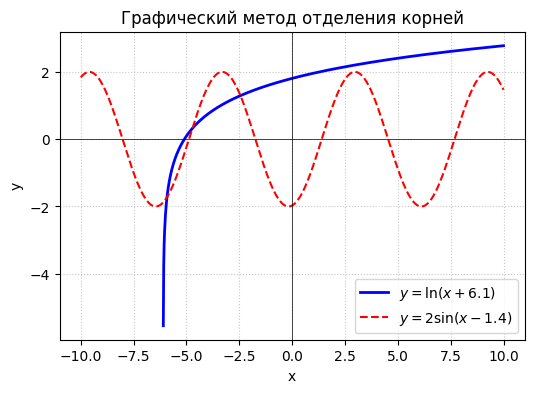

In [14]:
def f1(x):
        return np.log(x + 6.1)

def f2(x):
        return 2 * np.sin(x - 1.4)

# Область определения ln(x + 6.1): x > -6.1
# Выбираю диапазон x для визуализации

x = np.linspace(-10.0, 10, 1000)

# Графики
plt.figure(figsize=(6, 4))
plt.plot(x, f1(x), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x, f2(x), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')

# Оформление графика (Заголовок, оси координат, легенда)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

### Work2

In [13]:
# Определяем функцию f(x) = ln(x + 6.1) - 2*sin(x - 1.4)
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def bisection_method(a, b, eps):

    # Проверка условия теоремы Больцано-Коши
    if f(a) * f(b) > 0:
        print("На данном отрезке корней нет или их четное количество")
        return None

    while (b - a) / 2 > eps:
        
        mid = (a + b) / 2

        # Выбираем половину отрезка, на которой функция меняет знак
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid

    return (a + b) / 2

# Исходя из графического анализа, корень лежит в интервале [-6, -5]
a, b = -6, -5
epsilon = 1e-3

root = bisection_method(a, b, epsilon)

if root is not None:
    print(f"Корень уравнения: {root:.3f}")

Корень уравнения: -5.921


### Work3

In [12]:
def phi(x):

    # Преобразованная функция x = exp(2*sin(x - 1.4)) - 6.1
    return np.exp(2 * np.sin(x - 1.4)) - 6.1

def simple_iteration(x0, eps):
    x_old = x0
    x_new = phi(x_old)
    iterations = 1

    # Итерируем, пока разность соседних приближений больше eps
    while abs(x_new - x_old) > eps:
        x_old = x_new
        x_new = phi(x_old)
        iterations += 1

    return x_new, iterations

# Параметры
x_start = -6.0  
precision = 1e-6

root, nit = simple_iteration(x_start, precision)

print(f"Корень уравнения: {root:.6f}")
print(f"Количество итераций: {nit}")

Корень уравнения: -5.921485
Количество итераций: 8


### Work4

In [ ]:
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def df(x):
    return 1 / (x + 6.1) - 2 * np.cos(x - 1.4)

def df2(x):
    return -1 / (x + 6.1)**2 + 2 * np.sin(x - 1.4)


def solve_combined(a, b, eps):
    x_n = a # Для метода хорд
    x_k = b # Для метода касательных
    
    # для метода касательных беру край, где f(x)*f''(x) > 0
    if f(a) * df2(a) < 0:
        x_n, x_k = b, a
    
    while abs(x_n - x_k) > eps:

        # Формула хорд
        x_n = x_n - (f(x_n) * (x_k - x_n)) / (f(x_k) - f(x_n))
        
        # Формула касательных
        x_k = x_k - f(x_k) / df(x_k)
        
    root = (x_n + x_k) / 2
    print(f"Корень: {root:.6f}")

a = -6.0
b = -5.0
eps = 1e-6

solve_combined(a, b, eps)


Корень: -4.722275


### Work5

In [ ]:
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)


x0 = -6.0 
root = fsolve(f, x0)[0]

# Вывод результата с заданной точностью 10^-6
print(f"Корень: {root:.6f}")


Найденный корень: -5.921485
